In [5]:
import os
import torch
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import sys
sys.path.insert(0, '../../src')
import utils

In [6]:
# ── Configure ──────────────────────────────────────────────────────────────────
results_path = '../../outputs/optimist/mdp_output/sensitivity_results.pt'
figures_dir  = '../../figures/optimist/mdp_output/sensitivity'
# ──────────────────────────────────────────────────────────────────────────────

os.makedirs(figures_dir, exist_ok=True)

res = torch.load(results_path, weights_only=False)

rho_S_range      = np.array(res['rho_S_range'])       # (n_rho,)
theta_star_range = np.array(res['theta_star_range'])   # (n_theta,)
eps_star         = np.array(res['eps_star'])           # (n_rho,)
us_mdp           = np.array(res['us_mdp'])             # (n_rho,)
P_mdp            = np.array(res['P_mdp'])              # (n_rho,)
A_mdp            = np.array(res['A_mdp'])              # (n_rho,)
P_true           = np.array(res['P_true'])             # (n_rho, n_theta)
A_true           = np.array(res['A_true'])             # (n_rho, n_theta)
p_optout_true    = np.array(res['p_optout_true'])      # (n_rho, n_theta)
us_true          = np.array(res['us_true'])            # (n_rho, n_theta)
params           = res['params']

print('Parameters:')
for k, v in params.items():
    print(f'  {k}: {v}')
print(f'\nrho_S values  : {rho_S_range.tolist()}')
print(f'theta* values : {theta_star_range.tolist()}')

Parameters:
  rho_A: 240
  T: 3
  n_max: 200
  c0: 48.9
  c1: 0.066
  kappa: 0.05
  theta_b: 0.5
  alpha_0: 2.0
  beta_0: 1.0
  device: cuda
  epsilon_max: 0.9
  tol: 1e-06
  n_episodes: 200000

rho_S values  : [240.0, 500.0, 1000.0, 2000.0, 3000.0, 4000.0, 5000.0, 6000.0, 7000.0, 8000.0, 9000.0, 10000.0]
theta* values : [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.85, 0.9]


## 1. Optimal subsidy $\varepsilon^*$ vs $\rho_S$

For each value of the social utility of approval $\rho_S$, Algorithm 1 (divide-and-conquer) finds the subsidy $\varepsilon^*$ that maximises the principal's expected social utility $U^S = \rho_S P_{\text{approval}} - \varepsilon^* A$ under the MDP's Beta-Binomial dynamics.

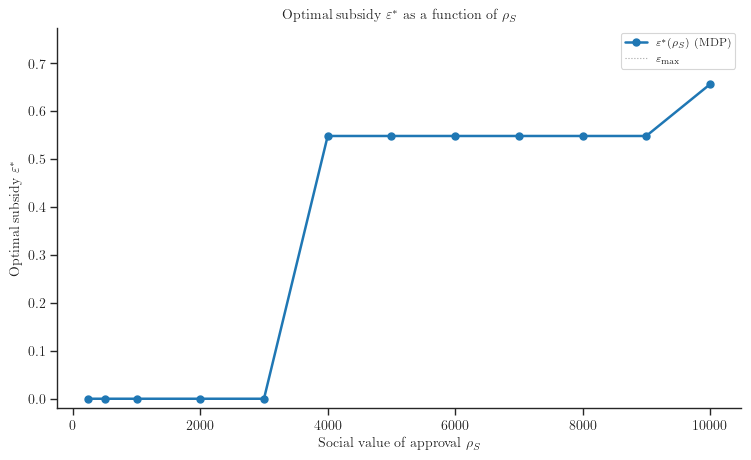

In [7]:
sns.set_theme(context='paper', style='ticks', font_scale=1)
utils.latexify()

width_pt = 1000
fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.55)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

palette = sns.color_palette('tab10')

ax.plot(rho_S_range, eps_star, 'o-', color=palette[0],
        linewidth=1.8, markersize=5, label=r'$\varepsilon^*(\rho_S)$ (MDP)')

ax.set_xlabel(r'Social value of approval $\rho_S$')
ax.set_ylabel(r'Optimal subsidy $\varepsilon^*$')
ax.set_title(r'Optimal subsidy $\varepsilon^*$ as a function of $\rho_S$')
ax.set_ylim(-0.02, max(eps_star) * 1.15 + 0.02)

# Reference line at epsilon_max
epsilon_max = float(params.get('epsilon_max', 1.0))
ax.axhline(epsilon_max, color='gray', lw=0.8, ls=':', alpha=0.7,
           label=r'$\varepsilon_{\max}$')

ax.legend(fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

fig.savefig(os.path.join(figures_dir, 'eps_star_vs_rhoS.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(figures_dir, 'eps_star_vs_rhoS.png'), dpi=200, bbox_inches='tight')

## 2. MDP social utility $U^S_{\text{MDP}}$ vs $\rho_S$

Social utility under the MDP (Beta-Binomial) dynamics at the optimal subsidy.

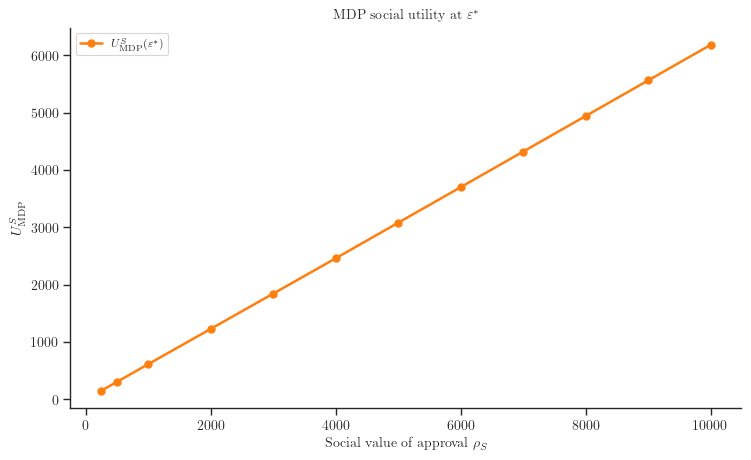

In [8]:
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

ax.plot(rho_S_range, us_mdp, 'o-', color=palette[1],
        linewidth=1.8, markersize=5, label=r'$U^S_{\mathrm{MDP}}(\varepsilon^*)$')

ax.set_xlabel(r'Social value of approval $\rho_S$')
ax.set_ylabel(r'$U^S_{\mathrm{MDP}}$')
ax.set_title(r'MDP social utility at $\varepsilon^*$')
ax.legend(fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

fig.savefig(os.path.join(figures_dir, 'us_mdp_vs_rhoS.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(figures_dir, 'us_mdp_vs_rhoS.png'), dpi=200, bbox_inches='tight')

## 3. True social utility $U^S_{\text{true}}$ vs $\rho_S$ (one curve per $\theta^*$)

For each $\theta^*$, the true social utility at the MDP-optimal subsidy $\varepsilon^*(\rho_S)$ is
$$
U^S_{\text{true}}(\varepsilon^*;\pi^*,\theta^*) = \rho_S\,P_{\text{true}}(\theta^*) - \varepsilon^* A_{\text{true}}(\theta^*)
$$
estimated via Monte Carlo under Binomial$(n, \theta^*)$ rollouts.

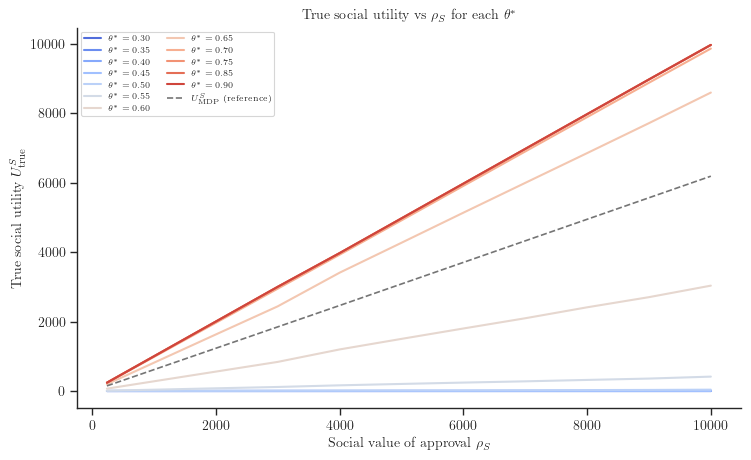

In [9]:
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

colors_theta = sns.color_palette('coolwarm', len(theta_star_range))

for j, theta_star in enumerate(theta_star_range):
    ax.plot(rho_S_range, us_true[:, j],
            color=colors_theta[j], linewidth=1.5,
            label=fr'$\theta^*={theta_star:.2f}$')

# Overlay MDP social utility for comparison
ax.plot(rho_S_range, us_mdp, 'k--', linewidth=1.2, alpha=0.6,
        label=r'$U^S_{\mathrm{MDP}}$ (reference)')

ax.set_xlabel(r'Social value of approval $\rho_S$')
ax.set_ylabel(r'True social utility $U^S_{\mathrm{true}}$')
ax.set_title(r'True social utility vs $\rho_S$ for each $\theta^*$')
ax.legend(fontsize=6, ncol=2, loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

fig.savefig(os.path.join(figures_dir, 'us_true_vs_rhoS.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(figures_dir, 'us_true_vs_rhoS.png'), dpi=200, bbox_inches='tight')

## 4. True opt-out probability (before approval) vs $\rho_S$ (one curve per $\theta^*$)

$P_{\theta^*}(\text{agent opts out before approval})$ under the MDP-optimal policy at $\varepsilon^*(\rho_S)$, evaluated via Monte Carlo rollouts.

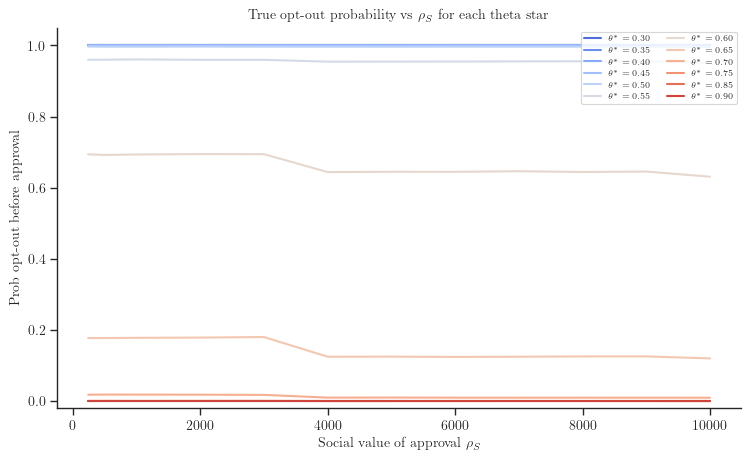

In [10]:
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

for j, theta_star in enumerate(theta_star_range):
    ax.plot(rho_S_range, p_optout_true[:, j],
            color=colors_theta[j], linewidth=1.5,
            label=fr'$\theta^*={theta_star:.2f}$')

ax.set_xlabel(r'Social value of approval $\rho_S$')
ax.set_ylabel(r'Prob opt-out before approval')
ax.set_title(r'True opt-out probability vs $\rho_S$ for each theta star')
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=6, ncol=2, loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

fig.savefig(os.path.join(figures_dir, 'p_optout_vs_rhoS.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(figures_dir, 'p_optout_vs_rhoS.png'), dpi=200, bbox_inches='tight')

## 5. True approval probability $P_{\text{true}}$ vs $\rho_S$ (one curve per $\theta^*$)

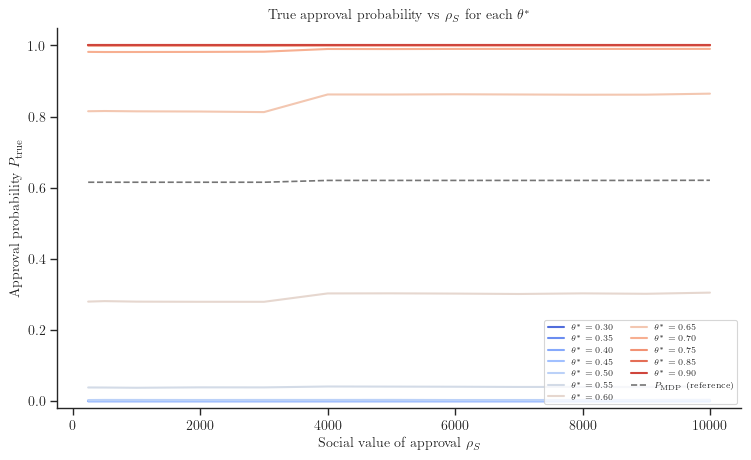

In [11]:
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

for j, theta_star in enumerate(theta_star_range):
    ax.plot(rho_S_range, P_true[:, j],
            color=colors_theta[j], linewidth=1.5,
            label=fr'$\theta^*={theta_star:.2f}$')

# MDP approval probability for reference
ax.plot(rho_S_range, P_mdp, 'k--', linewidth=1.2, alpha=0.6,
        label=r'$P_{\mathrm{MDP}}$ (reference)')

ax.set_xlabel(r'Social value of approval $\rho_S$')
ax.set_ylabel(r'Approval probability $P_{\mathrm{true}}$')
ax.set_title(r'True approval probability vs $\rho_S$ for each $\theta^*$')
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=6, ncol=2, loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

fig.savefig(os.path.join(figures_dir, 'P_true_vs_rhoS.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(figures_dir, 'P_true_vs_rhoS.png'), dpi=200, bbox_inches='tight')

## 6. Summary table

In [12]:
print(f"{'rho_S':>8}  {'eps*':>8}  {'U^S_mdp':>10}  {'P_mdp':>7}  {'A_mdp':>7}")
print('-' * 50)
for i, rho_S in enumerate(rho_S_range):
    print(f"{rho_S:8.1f}  {eps_star[i]:8.4f}  {us_mdp[i]:10.2f}  "
          f"{P_mdp[i]:7.4f}  {A_mdp[i]:7.2f}")

   rho_S      eps*     U^S_mdp    P_mdp    A_mdp
--------------------------------------------------
   240.0    0.0000      147.69   0.6154    36.19
   500.0    0.0000      307.69   0.6154    36.19
  1000.0    0.0000      615.39   0.6154    36.19
  2000.0    0.0000     1230.78   0.6154    36.19
  3000.0    0.0000     1846.17   0.6154    36.19
  4000.0    0.5486     2461.58   0.6205    37.03
  5000.0    0.5486     3082.05   0.6205    37.03
  6000.0    0.5486     3702.52   0.6205    37.03
  7000.0    0.5486     4323.00   0.6205    37.03
  8000.0    0.5486     4943.47   0.6205    37.03
  9000.0    0.5486     5563.94   0.6205    37.03
 10000.0    0.6564     6184.69   0.6209    37.22
